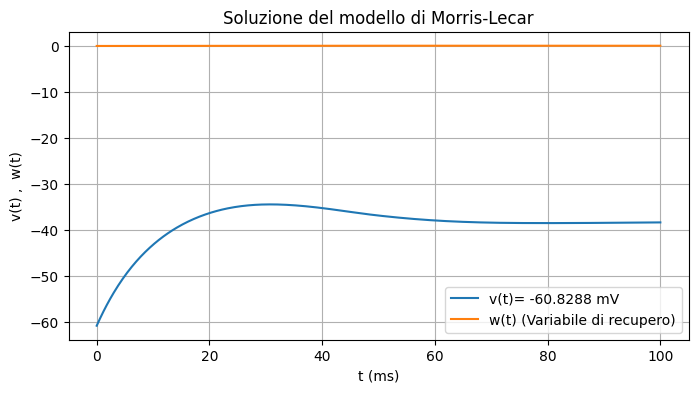

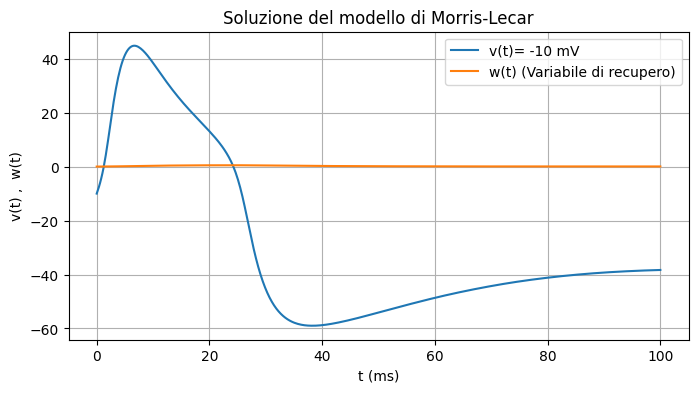

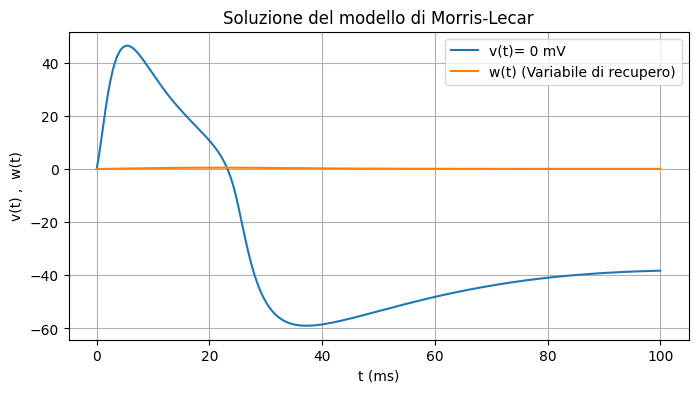

In [ ]:
import numpy as np
import matplotlib.pyplot as plt 
import scipy.linalg as la
from scipy.integrate import solve_ivp
from scipy.integrate import odeint

## MORRIS LECAR (ML) in 0D
def sech(x):
    return 1.0 / np.cosh(x)

def ML(t, y, I_app):
    v, w = y
    m_inf = 0.5 * (1 + np.tanh((v - v_1)/ v_2))
    w_inf = 0.5 * (1 + np.tanh((v - v_3)/ v_4))
    tau = (1.0/ phi) * sech((v - v_3)/ (2*v_4))
    #tau = max(1e-16, (1 / phi) * sech((v - v_3) / (2 * v_4)))

    dvdt = 1.0/C * ( -  g_ca * m_inf * (v - v_ca) - g_k * w * (v - v_k) - g_l * (v - v_l) + I_app)
    dwdt = (w_inf - w) / tau

    #if t % 5 == 0:  # Stampare ogni 10 unità di tempo
    #    print(f"t: {t}, v: {v}, w: {w}, dv/dt: {dvdt}, dw/dt: {dwdt}")

    return [dvdt, dwdt]

# Params

v0 = [- 60.8288, - 10, 0]#mV
w0 = 0.0149 
y0 = [v0, w0] 
C, phi, g_ca, g_k, g_l, v_ca, v_k, v_l, v_1, v_2, v_3, v_4 = 20, 0.04, 4.4, 8, 2, 130, -84, -60, -1.2, 18, 2, 30 
I_app = 55
T = 100
t = np.linspace(0, T, 500)

# solution
for i in v0 :
    plt.figure(figsize=(8, 4))

    sol = solve_ivp( ML, [0, T], [i, w0], args = (I_app,) , t_eval = t)
    v_sol = sol.y[0]
    w_sol = sol.y[1]
    plt.plot(t, v_sol, label=f"v(t)= {i} mV")
    plt.plot(t, w_sol,  label="w(t) (Variabile di recupero)")
    plt.xlabel("t (ms)")
    plt.ylabel("v(t) ,  w(t)")
    plt.title("Soluzione del modello di Morris-Lecar")
    plt.legend()
    plt.grid()
    plt.show()  

    ## lo spike parte se w sta bassa (tengo parametri fissi per ora). per I_app>> PA parte anche con v bassi (V<-10). se i_app = 0 , Pa parte con V=0

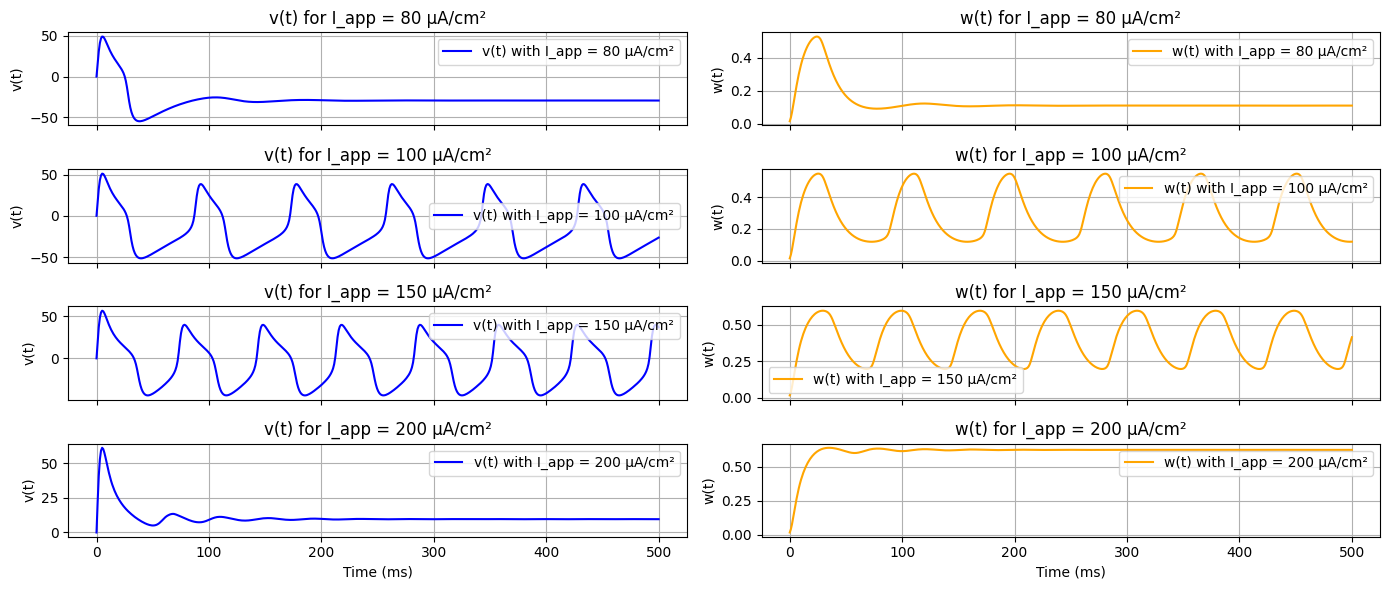

In [ ]:
I_app_list = [80, 100, 150, 200]
T, v0 = 500, 0
t = np.linspace(0, T, 500)
fig, axes = plt.subplots(len(I_app_list), 2, figsize=(14, 6), sharex=True)

for i, I_app in enumerate(I_app_list):
    sol = solve_ivp(ML, [0, T], [v0, w0], args=(I_app,), t_eval=t, method='RK45')
    v_sol = sol.y[0]
    w_sol = sol.y[1]

    axes[i, 0].plot(t, v_sol, label=f"v(t) with I_app = {I_app} µA/cm²", color='blue')
    axes[i, 0].set_ylabel("v(t)")
    axes[i, 0].set_title(f"v(t) for I_app = {I_app} µA/cm²")
    axes[i, 0].grid()
    axes[i, 0].legend()

    axes[i, 1].plot(t, w_sol, label=f"w(t) with I_app = {I_app} µA/cm²", color='orange')
    axes[i, 1].set_ylabel("w(t)")
    axes[i, 1].set_title(f"w(t) for I_app = {I_app} µA/cm²")
    axes[i, 1].grid()
    axes[i, 1].legend()

for ax in axes[-1, :]:
    ax.set_xlabel("Time (ms)")
plt.tight_layout()
plt.show()


# I_app >> depolarizza un tot la Vm -> W rimane alta per portare fuori K+ -> super iperpola non permette generazione di PA. 
# quindi c'è regime ottimale per innescare treno di PA


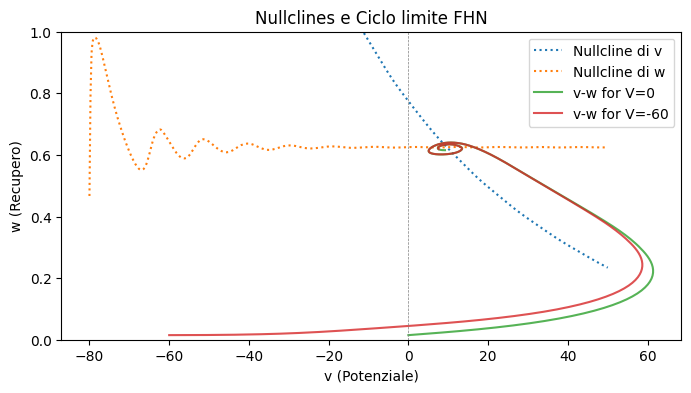

In [60]:
'''
dvdt = 0 con I_app = 0 -->  1/C ( f() - gk W dV) ) --> nuccline di v:  w = f()/ gkdV
dwdt = 0  per w_inf = w --> nullcline di w : w = w_inf

'''

## QUA USO V SOL , NELL'ALTRA V LINSPACE : SKE RISOLVO IL SISTEMA IN OGNI CASo

m_inf = 0.5 * (1 + np.tanh((v_sol - v_1)/ v_2))
w_inf = 0.5 * (1 + np.tanh((v_sol - v_3)/ v_4))

I_app =  200

def nullcline_v(v, I_app):
    return (- g_ca * m_inf * (v - v_ca) - g_l*(v - v_l) + I_app) / (g_k * (v - v_k))

def nullcline_w(v):
    return w_inf 

v = np.linspace(-80, 50, 500) 
w_v = nullcline_v(v, I_app)
w_w = nullcline_w(v)

# Plot
t = np.linspace(0, 100, 500)

plt.figure(figsize=(8, 4))
plt.plot(v, w_v, label="Nullcline di v", linestyle = ":")
plt.plot(v, w_w, label="Nullcline di w", linestyle = ":")

for i in (0, -60):
    sol = solve_ivp( ML, [0, 100], [i, 0.0149], args = (I_app,) , t_eval = t)
    plt.plot(sol.y[0], sol.y[1], label= f"v-w for V={i}", alpha = 0.8)


plt.axhline(0, color='gray', linewidth=0.5, linestyle='--')
plt.axvline(0, color='gray', linewidth=0.5, linestyle='--')
plt.xlabel("v (Potenziale)")
plt.ylabel("w (Recupero)")
#plt.xlim(-10, 30)
#plt.ylim(0.5, 1)
#plt.xlim([-80, 70])
plt.ylim([0, 1])
plt.title("Nullclines e Ciclo limite FHN")
plt.legend () #(loc='center left', bbox_to_anchor=(1, 0.5)) 
plt.show()

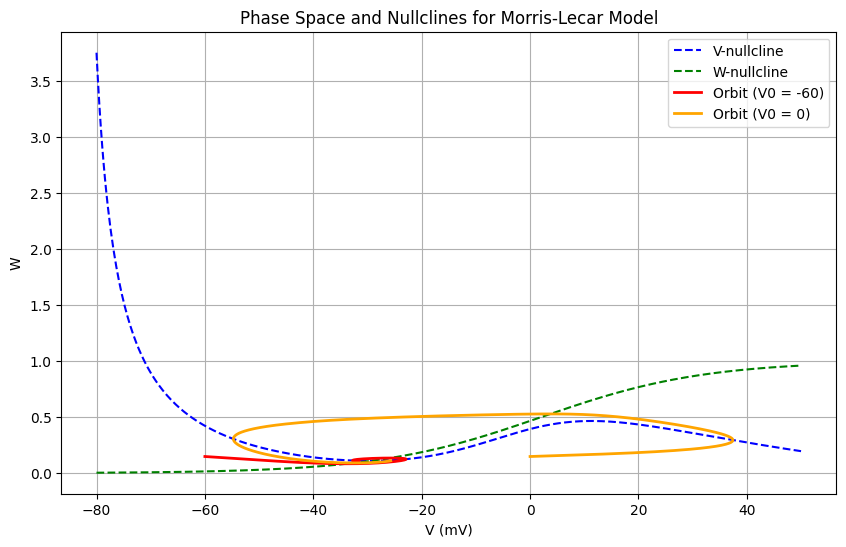

In [57]:
# Nullclines
def v_nullcline(v, I_app):
    m_inf = 0.5 * (1 + np.tanh((v - v_1) / v_2))
    return (1 / g_k) * (-g_ca * m_inf * (v - v_ca) - g_l * (v - v_l) + I_app) / (v - v_k)

def w_nullcline(v):
    return 0.5 * (1 + np.tanh((v - v_3) / v_4))

v_values = np.linspace(-80, 50, 500)
w_v_null = [v_nullcline(v, I_app=80) for v in v_values]
w_w_null = w_nullcline(v_values)

# Solve the system for V = -50 and V = 0
initial_conditions = [[-60, 0.149], [0, 0.149]]
trajectories = []

for ic in initial_conditions:
    sol = solve_ivp(ML, [0, 100], ic, args=(80,), dense_output=True)
    trajectories.append(sol.sol)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(v_values, w_v_null, label="V-nullcline", color="blue", linestyle="--")
plt.plot(v_values, w_w_null, label="W-nullcline", color="green", linestyle="--")

# Use distinct colors for orbits
colors = ['red', 'orange']
for i, trajectory in enumerate(trajectories):
    t_vals = np.linspace(0, 100, 1000)  # Time points for evaluation
    v_vals, w_vals = trajectory(t_vals)  # Evaluate the dense output
    plt.plot(v_vals, w_vals, label=f"Orbit (V0 = {initial_conditions[i][0]})", color=colors[i], linewidth=2)


plt.xlabel("V (mV)")
plt.ylabel("W")
plt.title("Phase Space and Nullclines for Morris-Lecar Model")
plt.legend()
plt.grid()
plt.show()